# KoChatGPT: 한국어 ChatGPT 구현 프로젝트

## RLHF (Reinforcement Learning from Human Feedback) 파이프라인

---

### 프로젝트 개요
이 노트북은 한국어 GPT-2 모델(KoGPT-2)을 출발점으로 삼아,  
ChatGPT와 동일한 방법론인 **RLHF 3단계 파이프라인**을 직접 구현합니다.

### 전체 흐름
```
[KoGPT-2 사전학습 모델]
        ↓  Step 1
[SFT: Supervised Fine-Tuning]   ← 지시문-응답 쌍으로 지도학습
        ↓  Step 2
[RM: Reward Model 학습]         ← 좋은 응답 vs 나쁜 응답 구별
        ↓  Step 3
[PPO: 강화학습 정렬]             ← 보상 최대화 방향으로 정책 업데이트
        ↓
[KoChatGPT 완성!]
```

### 사용 데이터셋
| 단계 | 파일명 | 설명 |
|------|--------|------|
| SFT | `kochatgpt_1_SFT.jsonl` | 지시문-응답 쌍 |
| RM | `kochatgpt_2_RM.jsonl` | 선호 응답 순위 데이터 |
| PPO | `kochatgpt_3_PPO.jsonl` | 지시문(프롬프트) 데이터 |

### 주요 라이브러리
- `transformers` : HuggingFace 모델/토크나이저
- `datasets` : 데이터셋 로드
- `trl` : PPO 트레이너 (RLHF 전용)
- `peft` / `loralib` : 파라미터 효율적 파인튜닝
- `accelerate` : 분산/가속 학습

---
## Step 0: 환경 설정 & 라이브러리 설치

필요한 패키지를 설치하고 기본 환경을 구성합니다.

In [2]:
# ── Cell 1 ──────────────────────────────────────────
# 필수 패키지 설치
# !pip install transformers datasets trl accelerate loralib peft
# !pip install torch torchvision
# !pip install sentencepiece  # 한국어 토크나이저

import os
import json
import torch
import numpy as np
from pathlib import Path

# 디렉토리 생성
os.makedirs("models", exist_ok=True)   # 모델 저장 폴더
os.makedirs("data", exist_ok=True)     # 데이터 저장 폴더
os.makedirs("logs", exist_ok=True)     # 학습 로그 폴더

# 디바이스 설정 (CUDA → MPS → CPU 순서로 확인)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")       # Apple Silicon (M1/M2/M3/M4) GPU
else:
    device = torch.device("cpu")

print(f"사용 디바이스: {device}")
print(f"PyTorch 버전: {torch.__version__}")

# 디바이스별 정보 출력
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    print("Apple Silicon MPS 가속 활성화!")
    print("통합 메모리(Unified Memory) 사용 중")

사용 디바이스: mps
PyTorch 버전: 2.8.0
Apple Silicon MPS 가속 활성화!
통합 메모리(Unified Memory) 사용 중


---
## Step 1: Base Model & Tokenizer 로드

### KoGPT-2 모델이란?
- **SKT**에서 공개한 한국어 GPT-2 모델
- 학습 데이터: 위키피디아, 나무위키, 뉴스 등 한국어 40GB
- 파라미터: 약 **125M** (1억 2500만개)
- HuggingFace 허브: `skt/kogpt2-base-v2`

> 이 모델은 텍스트를 이어서 생성하는 것만 잘 하고,
> 아직 사람의 "지시"를 따르거나 "대화"를 잘 하지는 못합니다.
> RLHF를 통해 이를 개선합니다!

In [3]:
# ── Cell 2 ──────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM

# 모델 이름 정의
MODEL_NAME = "skt/kogpt2-base-v2"

# 토크나이저 로드
# BOS(문장 시작), EOS(문장 끝), UNK(미등록 단어) 토큰을 '</s>'로 설정
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    bos_token='</s>',    # 문장 시작 토큰
    eos_token='</s>',    # 문장 끝 토큰
    unk_token='<unk>',   # 미등록 단어 토큰
    pad_token='<pad>',   # 패딩 토큰
)

print(f"Vocab 크기: {len(tokenizer)}")
print(f"특수 토큰: BOS={tokenizer.bos_token_id}, EOS={tokenizer.eos_token_id}, PAD={tokenizer.pad_token_id}")

# 모델 로드
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.to(device)

# 전체 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
print(f"\n전체 파라미터 수: {total_params:,}")
print(f"   (약 {total_params/1e6:.1f}M 파라미터)")

/Users/macminim4/PyCharmMiscProject/KoChatGPT/KoGptvenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Vocab 크기: 51200
특수 토큰: BOS=1, EOS=1, PAD=3

전체 파라미터 수: 125,164,032
   (약 125.2M 파라미터)


### Base Model 생성 테스트

SFT 전에 원래 모델이 어떻게 텍스트를 생성하는지 확인합니다.  
다양한 디코딩 전략을 비교해 봅니다.

| 전략 | 설명 | 특징 |
|------|------|------|
| Greedy | 매 스텝 가장 높은 확률 토큰 선택 | 결정적, 반복 발생 가능 |
| Beam Search | n개 후보 경로 동시 탐색 | 품질 좋음, 속도 느림 |
| Top-k Sampling | 상위 k개 토큰에서 랜덤 샘플링 | 다양성 향상 |
| Top-p (Nucleus) | 누적 확률 p 이하 토큰에서 샘플링 | 유연한 다양성 |

In [4]:
# ── Cell 3 ──────────────────────────────────────────
# 텍스트 생성 함수
def generate_text(prompt, strategy="greedy", max_length=100):
    """
    다양한 디코딩 전략으로 텍스트 생성
    
    Args:
        prompt (str): 입력 프롬프트
        strategy (str): 'greedy', 'beam', 'topk', 'topp' 중 선택
        max_length (int): 최대 생성 길이
    """
    # 입력 텍스트를 토큰 ID 시퀀스로 변환
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_len = inputs["input_ids"].shape[1]
    
    with torch.no_grad():
        if strategy == "greedy":
            # 탐욕적 디코딩: 매 스텝 확률 최고 토큰 선택
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                do_sample=False,      # 샘플링 OFF → 탐욕적
            )
        elif strategy == "beam":
            # 빔 서치: 5개 경로를 동시에 탐색
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                num_beams=5,          # 빔 개수
                no_repeat_ngram_size=2,  # 2-gram 반복 방지
                early_stopping=True,
            )
        elif strategy == "topk":
            # Top-k 샘플링: 상위 50개 토큰 중 랜덤 선택
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                do_sample=True,
                top_k=50,
                temperature=0.8,      # 온도 낮을수록 보수적 선택
            )
        elif strategy == "topp":
            # Top-p (Nucleus) 샘플링
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                do_sample=True,
                top_p=0.92,          # 누적 확률 92% 이내 토큰만 사용
                temperature=1.0,
            )
    
    # 생성된 토큰을 다시 텍스트로 변환 (입력 부분 제외)
    generated = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)
    return generated

# 테스트 실행
test_prompt = "불고기용 고기 한우에요?"

print("=" * 60)
print(f"입력 프롬프트: {test_prompt}")
print("=" * 60)

for strategy in ["greedy", "beam", "topk", "topp"]:
    result = generate_text(test_prompt, strategy=strategy)
    print(f"\n[{strategy.upper():10s}] {result}")

입력 프롬프트: 불고기용 고기 한우에요?

[GREEDY    ] !
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이렇게 맛있는 고기 한우를 먹으니까
이

[BEAM      ] ᄒᄒ
이거 진짜 맛있더라구요 ᄏᄏ
고기랑 같이 먹으니까 더 맛있어요!!!
이렇게 고기랑 함께 먹을 수 있어서 너무 좋았어요~~
고기가 정말 맛있게 잘 익었습니다!
고기를 구워먹을 수 있는 고기집이라고 하네요!
고기집답게 고기 굽는 과정이 굉장히 간단하답니다  
고기 굽기

[TOPK      ] ᄒᄒ
예전에는 그냥 고기 한 번에 먹었는데
안먹으면 더더욱 안먹을 것 같아요~!
오늘은 쭈꾸미랑 버섯볶음밥이 나왔어요~
오징어 한마리가 등장!
얼마전 먹었는데 더 맛있었던 쭈꾸미랑 버섯볶음밥!
그리고 버섯볶음밥도 맛있더라구요!
버섯볶음밥은 정말 맛있고


[TOPP      ] !
저는 한우등심을 맛있게 먹었습니다.
한우의 깊은 풍미는 살찌지 않고 더욱 맛있게 즐길 수 있게 하는 밑반찬인 만큼..ᄒᄒ
여기 나온 메뉴는 소고기의 향과 불고기맛의 향, 그리고 불고기맛에 불고기 소고기의 맛과 향이 풍성하게 어우러진 한우등심의 본고장인 이곳에도 맛있게 먹었습니다.
이날, 오랜만에 먹었던 한우등심!


### 🧪 직접 실험! — 나만의 프롬프트로 Base 모델 테스트

> **바로 실행 가능합니다** (Cell 1, 2, 3 실행 후)  
> `MY_PROMPT`와 `MY_STRATEGY`를 바꿔가며 실험해보세요!

In [9]:
# ── 실험 Cell A: 나만의 프롬프트 테스트 ────────────────────────────
# ✅ 바로 실행 가능! MY_PROMPT 를 원하는 질문으로 바꿔보세요

MY_PROMPT   = "오늘 저녁 뭐 먹을까요?"  # ← 여기를 바꿔보세요!
MY_STRATEGY = "beam"                   # 'greedy' / 'beam' / 'topk' / 'topp'
MY_MAX_LEN  = 80                       # 생성 길이 (50~200)

print("=" * 60)
print(f"프롬프트  : {MY_PROMPT}")
print(f"전략      : {MY_STRATEGY}")
print("=" * 60)

result = generate_text(MY_PROMPT, strategy=MY_STRATEGY, max_length=MY_MAX_LEN)
print(f"\n[Base 모델 응답]\n{result}")

print("\n" + "-" * 60)
print("실험 힌트:")
print("  greedy → 항상 동일한 결과 (결정적)")
print("  topk   → 실행할 때마다 다른 결과 (확률적)")
print("  MY_MAX_LEN = 150 → 더 긴 응답 생성")


프롬프트  : 오늘 저녁 뭐 먹을까요?
전략      : beam

[Base 모델 응답]
"
"아니야. 그건 그렇고."
"그런데 그게 무슨 소리야? 그걸 어떻게 알았어? 아, 그거야."
그녀는 고개를 끄덕였다.
"어떻게 알았을까?"
그녀의 눈에서 눈물이 흘러내리고 있었다.
"그래, 알았다."
그러자 그녀는 다시 한 번 그녀의 손을 잡았다.
"

------------------------------------------------------------
실험 힌트:
  greedy → 항상 동일한 결과 (결정적)
  topk   → 실행할 때마다 다른 결과 (확률적)
  MY_MAX_LEN = 150 → 더 긴 응답 생성


---
## Step 2: 데이터셋 로드 & 탐색

### 3가지 데이터셋 구조

#### 1. SFT 데이터 (`kochatgpt_1_SFT.jsonl`)
```json
{
  "prompt": "불고기용 고기 한우에요?",
  "completion": "네, 불고기용으로는 한우 채끝이나 등심을 추천드립니다..."
}
```

#### 2. RM 데이터 (`kochatgpt_2_RM.jsonl`)
```json
{
  "prompt": "...",
  "chosen": "더 좋은 응답",
  "rejected": "더 나쁜 응답"
}
```

#### 3. PPO 데이터 (`kochatgpt_3_PPO.jsonl`)
```json
{
  "prompt": "강화학습에 사용될 지시문"
}
```

In [36]:
# ── Cell 4 ──────────────────────────────────────────
import json

# 데이터 로드 함수 (JSON 배열 및 JSONL 형식 모두 지원)
def load_jsonl(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read().strip()
    if content.startswith("["):
        return json.loads(content)
    return [json.loads(l) for l in content.splitlines() if l.strip()]

from datasets import Dataset

print("데이터셋 로드 중...")

sft_data = load_jsonl("data/kochatgpt_1_SFT.jsonl")
rm_data  = load_jsonl("data/kochatgpt_2_RM.jsonl")
ppo_data = load_jsonl("data/kochatgpt_3_PPO.jsonl")

sft_dataset = Dataset.from_list(sft_data)
rm_dataset  = Dataset.from_list(rm_data)
ppo_dataset = Dataset.from_list(ppo_data)

print(f"SFT 데이터: {len(sft_dataset)}개 샘플")
print(f"RM 데이터:  {len(rm_dataset)}개 샘플")
print(f"PPO 데이터: {len(ppo_dataset)}개 샘플")

print("=" * 60)
print("SFT 데이터 샘플:")
print("=" * 60)
sample = sft_dataset[0]
print("[Prompt]")
print(sample.get("prompt", sample.get("instruction", "")))
print("[Completion]")
print(sample.get("completion", sample.get("output", "")))


데이터셋 로드 중...
SFT 데이터: 12000개 샘플
RM 데이터:  10220개 샘플
PPO 데이터: 12000개 샘플
SFT 데이터 샘플:
[Prompt]
불고기용 고기 한우에요?
[Completion]
'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.


---
## Step 2-A: 데이터 EDA (탐색적 데이터 분석)

데이터 품질을 확인합니다. 길이 분포, 중복, 짧은 문장 등을 분석합니다.

In [37]:
# ── Cell 5: EDA 기본 통계 분석 ──────────────────────────────
import pandas as pd

# ── SFT 데이터 분석 ──
sft_df = pd.DataFrame(sft_data)
sft_df["prompt_len"]     = sft_df["prompt"].str.len()
sft_df["completion_len"] = sft_df["completion"].str.len()

print("=" * 60)
print("[ SFT 데이터 기본 통계 ]")
print("=" * 60)
print(f"총 샘플 수       : {len(sft_df):,}개")
print(f"중복 prompt 수   : {sft_df['prompt'].duplicated().sum():,}개")
print(f"\n[prompt 길이]")
print(sft_df["prompt_len"].describe().to_string())
print(f"\n[completion 길이]")
print(sft_df["completion_len"].describe().to_string())

# ── RM 데이터 분석 ──
# 실제 컬럼: prompt / completion_0 / completion_1 / completion_2 / ranking
# ranking[i] = completion_i의 순위 (0=최고, 2=최저)
rm_df = pd.DataFrame(rm_data)
print(f"\n[ RM 실제 컬럼: {list(rm_df.columns)} ]")

rm_df["prompt_len"]      = rm_df["prompt"].str.len()
rm_df["completion_0_len"] = rm_df["completion_0"].str.len()
rm_df["completion_1_len"] = rm_df["completion_1"].str.len()
rm_df["completion_2_len"] = rm_df["completion_2"].str.len()

# ranking에서 chosen(0위)/rejected(2위) 텍스트 추출
def get_chosen(row):
    best_idx = row["ranking"].index(0)   # 순위 0 = 가장 좋은 응답
    return row[f"completion_{best_idx}"]

def get_rejected(row):
    worst_idx = row["ranking"].index(2)  # 순위 2 = 가장 나쁜 응답
    return row[f"completion_{worst_idx}"]

rm_df["chosen"]   = rm_df.apply(get_chosen, axis=1)
rm_df["rejected"] = rm_df.apply(get_rejected, axis=1)
rm_df["chosen_len"]   = rm_df["chosen"].str.len()
rm_df["rejected_len"] = rm_df["rejected"].str.len()

print("\n" + "=" * 60)
print("[ RM 데이터 기본 통계 ]")
print("=" * 60)
print(f"총 샘플 수         : {len(rm_df):,}개")
print(f"중복 prompt 수     : {rm_df['prompt'].duplicated().sum():,}개")
print(f"\n[chosen 길이]    평균: {rm_df['chosen_len'].mean():.1f} / 최대: {rm_df['chosen_len'].max()}")
print(f"[rejected 길이]  평균: {rm_df['rejected_len'].mean():.1f} / 최대: {rm_df['rejected_len'].max()}")

# ── PPO 데이터 분석 ──
ppo_df = pd.DataFrame(ppo_data)
ppo_df["prompt_len"] = ppo_df["prompt"].str.len()

print("\n" + "=" * 60)
print("[ PPO 데이터 기본 통계 ]")
print("=" * 60)
print(f"총 샘플 수       : {len(ppo_df):,}개")
print(f"중복 prompt 수   : {ppo_df['prompt'].duplicated().sum():,}개")
print(f"prompt 길이      평균: {ppo_df['prompt_len'].mean():.1f} / 최대: {ppo_df['prompt_len'].max()}")

[ SFT 데이터 기본 통계 ]
총 샘플 수       : 12,000개
중복 prompt 수   : 54개

[prompt 길이]
count    12000.000000
mean        22.180583
std         14.110028
min          0.000000
25%         13.000000
50%         19.000000
75%         28.000000
max        295.000000

[completion 길이]
count    12000.000000
mean       144.107250
std        122.843692
min          4.000000
25%         62.000000
50%        118.000000
75%        185.000000
max       1553.000000

[ RM 실제 컬럼: ['prompt', 'completion_0', 'completion_1', 'completion_2', 'ranking'] ]

[ RM 데이터 기본 통계 ]
총 샘플 수         : 10,220개
중복 prompt 수     : 39개

[chosen 길이]    평균: 129.7 / 최대: 3681
[rejected 길이]  평균: 118.3 / 최대: 3694

[ PPO 데이터 기본 통계 ]
총 샘플 수       : 12,000개
중복 prompt 수   : 54개
prompt 길이      평균: 22.2 / 최대: 295


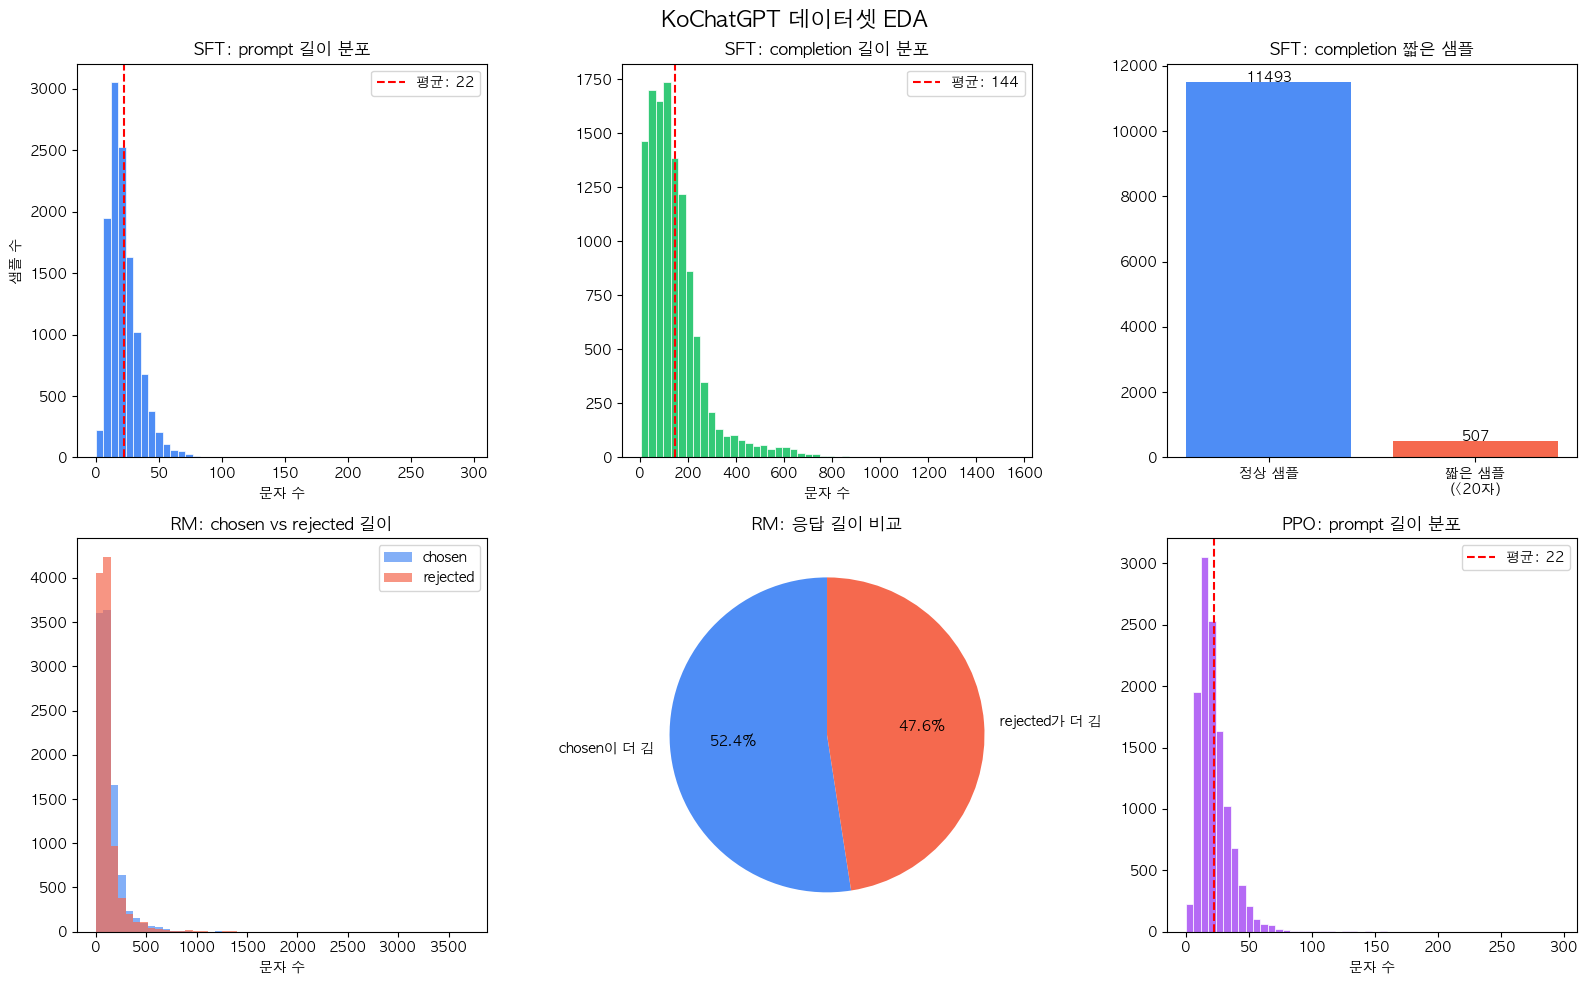

시각화 저장: logs/eda_visualization.png


In [38]:
# ── Cell 6: EDA 길이 분포 시각화 ──────────────────────────────
import matplotlib
import matplotlib.pyplot as plt

# 한국어 폰트 설정 (macOS)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("KoChatGPT 데이터셋 EDA", fontsize=16, fontweight="bold")

# ── SFT: prompt 길이 ──
axes[0, 0].hist(sft_df["prompt_len"], bins=50, color="#4e8df5", edgecolor="white", linewidth=0.5)
axes[0, 0].set_title("SFT: prompt 길이 분포")
axes[0, 0].set_xlabel("문자 수")
axes[0, 0].set_ylabel("샘플 수")
axes[0, 0].axvline(sft_df["prompt_len"].mean(), color="red", linestyle="--", label=f"평균: {sft_df['prompt_len'].mean():.0f}")
axes[0, 0].legend()

# ── SFT: completion 길이 ──
axes[0, 1].hist(sft_df["completion_len"], bins=50, color="#34c977", edgecolor="white", linewidth=0.5)
axes[0, 1].set_title("SFT: completion 길이 분포")
axes[0, 1].set_xlabel("문자 수")
axes[0, 1].axvline(sft_df["completion_len"].mean(), color="red", linestyle="--", label=f"평균: {sft_df['completion_len'].mean():.0f}")
axes[0, 1].legend()

# ── SFT: 짧은 completion 확인 ──
short_mask = sft_df["completion_len"] < 20
axes[0, 2].bar(["정상 샘플", "짧은 샘플\n(<20자)"],
               [len(sft_df) - short_mask.sum(), short_mask.sum()],
               color=["#4e8df5", "#f5694e"])
axes[0, 2].set_title("SFT: completion 짧은 샘플")
for i, v in enumerate([len(sft_df) - short_mask.sum(), short_mask.sum()]):
    axes[0, 2].text(i, v + 10, str(v), ha="center", fontweight="bold")

# ── RM: chosen vs rejected 길이 비교 ──
axes[1, 0].hist(rm_df["chosen_len"],   bins=50, alpha=0.7, color="#4e8df5", label="chosen")
axes[1, 0].hist(rm_df["rejected_len"], bins=50, alpha=0.7, color="#f5694e", label="rejected")
axes[1, 0].set_title("RM: chosen vs rejected 길이")
axes[1, 0].set_xlabel("문자 수")
axes[1, 0].legend()

# ── RM: chosen이 rejected보다 긴 비율 ──
chosen_longer = (rm_df["chosen_len"] > rm_df["rejected_len"]).sum()
axes[1, 1].pie([chosen_longer, len(rm_df) - chosen_longer],
               labels=["chosen이 더 김", "rejected가 더 김"],
               colors=["#4e8df5", "#f5694e"],
               autopct="%1.1f%%", startangle=90)
axes[1, 1].set_title("RM: 응답 길이 비교")

# ── PPO: prompt 길이 ──
axes[1, 2].hist(ppo_df["prompt_len"], bins=50, color="#b56af5", edgecolor="white", linewidth=0.5)
axes[1, 2].set_title("PPO: prompt 길이 분포")
axes[1, 2].set_xlabel("문자 수")
axes[1, 2].axvline(ppo_df["prompt_len"].mean(), color="red", linestyle="--", label=f"평균: {ppo_df['prompt_len'].mean():.0f}")
axes[1, 2].legend()

plt.tight_layout()
plt.savefig("logs/eda_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("시각화 저장: logs/eda_visualization.png")

In [39]:
# ── Cell 7: EDA 데이터 정제 & 저장 ──────────────────────────────
import os

def clean_sft(df, min_prompt=5, min_completion=20, max_completion=1000):
    """SFT 데이터 정제"""
    before = len(df)
    df = df[df["prompt_len"] >= min_prompt]
    df = df[df["completion_len"] >= min_completion]
    df = df[df["completion_len"] <= max_completion]
    df = df.drop_duplicates(subset=["prompt"])
    after = len(df)
    print(f"  SFT: {before:,} → {after:,}개 (제거: {before-after:,}개)")
    return df

def clean_rm(df, min_len=10, max_len=1000):
    """
    RM 데이터 정제
    ranking에서 chosen(0위)/rejected(2위) 쌍을 만들고 필터링
    """
    before = len(df)
    df = df[df["chosen_len"] >= min_len]
    df = df[df["rejected_len"] >= min_len]
    df = df[df["chosen_len"] <= max_len]
    df = df[df["rejected_len"] <= max_len]
    df = df[df["chosen"] != df["rejected"]]   # 완전히 같은 쌍 제거
    df = df.drop_duplicates(subset=["prompt"])
    after = len(df)
    print(f"  RM : {before:,} → {after:,}개 (제거: {before-after:,}개)")
    return df

def clean_ppo(df, min_prompt=5, max_prompt=200):
    """PPO 데이터 정제"""
    before = len(df)
    df = df[df["prompt_len"] >= min_prompt]
    df = df[df["prompt_len"] <= max_prompt]
    df = df.drop_duplicates(subset=["prompt"])
    after = len(df)
    print(f"  PPO: {before:,} → {after:,}개 (제거: {before-after:,}개)")
    return df

print("=" * 60)
print("데이터 정제 시작")
print("=" * 60)
sft_clean = clean_sft(sft_df)
rm_clean  = clean_rm(rm_df)
ppo_clean = clean_ppo(ppo_df)

# 정제된 데이터 저장
# RM은 chosen/rejected 쌍으로 변환해서 저장
os.makedirs("data/cleaned", exist_ok=True)

sft_clean[["prompt", "completion"]].to_json(
    "data/cleaned/sft_clean.jsonl", orient="records", lines=True, force_ascii=False)

rm_clean[["prompt", "chosen", "rejected"]].to_json(
    "data/cleaned/rm_clean.jsonl", orient="records", lines=True, force_ascii=False)

ppo_clean[["prompt"]].to_json(
    "data/cleaned/ppo_clean.jsonl", orient="records", lines=True, force_ascii=False)

print("\n정제 완료! 저장 위치: data/cleaned/")
print(f"  sft_clean.jsonl  : {len(sft_clean):,}개")
print(f"  rm_clean.jsonl   : {len(rm_clean):,}개  ← chosen/rejected 쌍으로 변환됨")
print(f"  ppo_clean.jsonl  : {len(ppo_clean):,}개")

데이터 정제 시작
  SFT: 12,000 → 11,316개 (제거: 684개)
  RM : 10,220 → 9,502개 (제거: 718개)
  PPO: 12,000 → 11,821개 (제거: 179개)

정제 완료! 저장 위치: data/cleaned/
  sft_clean.jsonl  : 11,316개
  rm_clean.jsonl   : 9,502개  ← chosen/rejected 쌍으로 변환됨
  ppo_clean.jsonl  : 11,821개


---
## Step 3: Supervised Fine-Tuning (SFT)

### SFT란?
사람이 작성한 **질문(지시문) + 좋은 응답** 쌍을 이용해 모델을 파인튜닝합니다.

### 핵심 아이디어: Source Masking (소스 마스킹)
```
입력:  [지시문 토큰들] [응답 토큰들]
레이블: [-100, -100, ...] [응답 토큰들]  ← 지시문 부분은 손실 계산에서 제외!
```
왜? 모델이 **응답 생성**만 학습하도록 하기 위해서입니다.  
지시문 토큰에 `-100`을 넣으면 CrossEntropyLoss가 해당 위치를 무시합니다.

### 데이터 형식
```
<지시문> 불고기용 고기 한우에요? </s> <응답> 네, 한우 채끝을 추천드립니다. </s>
```

In [40]:
# ── Cell 8: SFTDataset 클래스 정의 ──────────────────────────────
from torch.utils.data import Dataset as TorchDataset, DataLoader
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

class SFTDataset(TorchDataset):
    """
    Supervised Fine-Tuning을 위한 데이터셋
    - 지시문(prompt)과 응답(completion)을 하나의 시퀀스로 합침
    - 지시문 부분의 레이블을 -100으로 마스킹 (손실 계산 제외)
    """
    def __init__(self, dataset, tokenizer, max_length=512):
        self.data = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        prompt     = sample.get('prompt', sample.get('instruction', ''))
        completion = sample.get('completion', sample.get('output', ''))

        prompt_tokens = self.tokenizer(
            prompt, return_tensors="pt", truncation=True,
            max_length=self.max_length // 2,
        )
        prompt_len = prompt_tokens["input_ids"].shape[1]

        full_text = prompt + " " + completion + self.tokenizer.eos_token
        full_tokens = self.tokenizer(
            full_text, return_tensors="pt", truncation=True,
            max_length=self.max_length, padding="max_length",#"max_length" 옵션=512 이름 변수 max_length 아님
        )

        input_ids      = full_tokens["input_ids"].squeeze()
        attention_mask = full_tokens["attention_mask"].squeeze()

        labels = input_ids.clone()
        labels[:prompt_len]          = -100   # 지시문 → 손실 무시
        labels[attention_mask == 0]  = -100   # 패딩   → 손실 무시

        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


class SFTDataCollator:
    """배치 내 시퀀스를 같은 길이로 맞추는 콜레이터"""
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch):
        return {
            "input_ids":      torch.stack([b["input_ids"]      for b in batch]),
            "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
            "labels":         torch.stack([b["labels"]         for b in batch]),
        }

print("Cell 8: SFTDataset 클래스 정의 완료")

Cell 8: SFTDataset 클래스 정의 완료


In [41]:
# ── Cell 9: SFT 학습 설정 ──────────────────────────────
SFT_CONFIG = {
    "output_dir": "models/output_1_SFT",
    "num_train_epochs": 1,
    "per_device_train_batch_size": 8,
    "warmup_steps": 5,
    "learning_rate": 5e-5,
    "fp16": torch.cuda.is_available(),                  # FP16: CUDA 전용
    "bf16": torch.backends.mps.is_available(),          # BF16: MPS(Apple Silicon) 전용
    "logging_steps": 10,
    "save_steps": 100,
}

training_args = TrainingArguments(**SFT_CONFIG)

print("Cell 9: SFT 학습 설정")
for k, v in SFT_CONFIG.items():
    print(f"   {k}: {v}")

# ── 실제 SFT 학습 실행 ──
sft_train_dataset = SFTDataset(sft_dataset, tokenizer)
collator = SFTDataCollator(tokenizer)#데이터 수집 tensor 화 , batch화
trainer = Trainer(
    model=model, args=training_args,   #model은 skt/kogpt2-base-v2
    train_dataset=sft_train_dataset, data_collator=collator,
)
print("\nSFT 학습 시작! (MPS M4 기준 약 20-40분)")
trainer.train()# 여기서 벡터화 된다
#우리는 그저 **"정수 번호표(input_ids)"**만 잘 준비해서 trainer.train()에 넘겨주기만 하면
# #모델이 입구에서 알아서 이를 벡터로 바꾸어 학습을 진행하는 구조입니다.
trainer.save_model("models/output_1_SFT")
print("SFT 모델 저장 완료: models/output_1_SFT")


Cell 9: SFT 학습 설정
   output_dir: models/output_1_SFT
   num_train_epochs: 1
   per_device_train_batch_size: 8
   warmup_steps: 5
   learning_rate: 5e-05
   fp16: False
   bf16: True
   logging_steps: 10
   save_steps: 100

SFT 학습 시작! (MPS M4 기준 약 20-40분)


/Users/macminim4/PyCharmMiscProject/KoChatGPT/KoGptvenv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,3.863400
20,3.633600
30,3.387800
40,3.381200
50,3.252500
60,3.163700
70,3.236500
80,3.220700
90,2.984900
100,3.267400


SFT 모델 저장 완료: models/output_1_SFT


### 🧪 직접 실험! — 미니 SFT 학습 체험 (50개 샘플, 약 1-2분)

> **Cell 8, 9 실행 후 이 셀을 실행하세요**  
> 실제로 SFT 학습 1 에폭이 돌아갑니다!  
> `MINI_SAMPLES`를 늘리면 학습 시간도 늘어납니다.

In [43]:
# ── 실험 Cell B: 미니 SFT 학습 체험 ────────────────────────────
# ✅ 50개 샘플로 실제 SFT 학습을 경험해보세요 (MPS 약 1-2분)
import random
from datasets import Dataset as HFDataset  # torch Dataset과 이름 충돌 방지

MINI_SAMPLES = 50    # ← 늘리면 더 오래 (100→약 3분, 500→약 15분)
MINI_EPOCHS  = 1

print(f"미니 SFT 학습 시작 ({MINI_SAMPLES}개 샘플, {MINI_EPOCHS}에폭)")
print(f"디바이스: {device}")

# 랜덤 샘플 추출
random.seed(42)
mini_indices = random.sample(range(len(sft_data)), MINI_SAMPLES)
mini_raw     = [sft_data[i] for i in mini_indices]
mini_dataset_raw = HFDataset.from_list(mini_raw)

mini_sft_dataset = SFTDataset(mini_dataset_raw, tokenizer, max_length=256)
mini_collator    = SFTDataCollator(tokenizer)

mini_args = TrainingArguments(
    output_dir               = "models/output_mini_SFT",
    num_train_epochs         = MINI_EPOCHS,
    per_device_train_batch_size = 4,
    learning_rate            = 5e-5,
    fp16                     = torch.cuda.is_available(),
    bf16                     = torch.backends.mps.is_available(),
    logging_steps            = 5,
    save_steps               = 9999,  # 저장 안 함 (실험용)
    report_to                = "none",
)

mini_trainer = Trainer(
    model         = model,
    args          = mini_args,
    train_dataset = mini_sft_dataset,
    data_collator = mini_collator,
)

mini_trainer.train()
print("\n미니 SFT 학습 완료!")
print("아래 셀 C에서 응답이 어떻게 바뀌었는지 확인하세요.")


미니 SFT 학습 시작 (50개 샘플, 1에폭)
디바이스: mps


/Users/macminim4/PyCharmMiscProject/KoChatGPT/KoGptvenv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
5,2.429500
10,2.355900



미니 SFT 학습 완료!
아래 셀 C에서 응답이 어떻게 바뀌었는지 확인하세요.


### 🧪 직접 실험! — 미니 SFT 전후 응답 비교

> **셀 B 실행 완료 후** 이 셀을 실행하세요.  
> 같은 프롬프트에 대해 학습 전/후 응답을 비교합니다.

In [44]:
# ── 실험 Cell C: 미니 SFT 후 응답 확인 ────────────────────────────
# ✅ 셀 B 실행 완료 후 이 셀을 실행하세요!

MY_TEST_PROMPT = "오늘 저녁 뭐 먹을까요?"   # ← 셀 A와 같은 프롬프트로 비교!

print("=" * 60)
print(f"테스트 프롬프트: {MY_TEST_PROMPT}")
print("=" * 60)

# 미니 SFT가 적용된 현재 model로 생성
result_after = generate_text(MY_TEST_PROMPT, strategy="beam", max_length=100)
print(f"\n[미니 SFT 후 응답]\n{result_after}")

print("\n" + "-" * 60)
print("참고:")
print("  - 50개 샘플 학습이라 큰 변화는 없을 수 있어요")
print("  - Cell 9 주석 해제 → 11,316개 전체 학습 시 뚜렷하게 달라집니다")
print("  - 전체 학습 시간: MPS(M4) 약 20-40분")


테스트 프롬프트: 오늘 저녁 뭐 먹을까요?

[미니 SFT 후 응답]
'저는 AI 어시스턴트이기 때문에 아침 식사를 제공할 수 없습니다. 하지만 대부분의 음식점에서는 저녁 메뉴를 제공합니다.

------------------------------------------------------------
참고:
  - 50개 샘플 학습이라 큰 변화는 없을 수 있어요
  - Cell 9 주석 해제 → 11,316개 전체 학습 시 뚜렷하게 달라집니다
  - 전체 학습 시간: MPS(M4) 약 20-40분


### SFT 모델 추론 테스트

SFT 학습 후 모델이 지시문을 잘 따르는지 확인합니다.

In [45]:
# ── Cell 10: SFT 모델 추론 테스트 ──────────────────────────────
from transformers import pipeline

def get_pipeline_device():
    """디바이스 인덱스 반환 (pipeline 전용)"""
    if torch.cuda.is_available():
        return 0        # CUDA GPU 0번
    elif torch.backends.mps.is_available():
        return "mps"    # Apple Silicon MPS
    else:
        return -1       # CPU

def test_sft_model(model_path="models/output_1_SFT"):
    """학습된 SFT 모델로 텍스트 생성 테스트"""
    try:
        generator = pipeline(
            "text-generation", model=model_path,
            tokenizer=tokenizer, device=get_pipeline_device(),
        )
        test_prompts = [
            "불고기용 고기 한우에요?",
            "파이썬으로 리스트를 정렬하는 방법을 알려줘",
            "오늘 날씨가 좋네요",
        ]
        print("=" * 60)
        print("SFT 모델 테스트 결과")
        print("=" * 60)
        for prompt in test_prompts:
            result = generator(
                prompt, max_new_tokens=50, num_beams=5,
                repetition_penalty=1.2, no_repeat_ngram_size=2,
            )
            print(f"\n[입력] {prompt}")
            print(f"[출력] {result[0]['generated_text']}")
    except Exception as e:
        print(f"모델 로드 실패 (SFT 학습 후 실행하세요): {e}")

test_sft_model()

Device set to use mps


SFT 모델 테스트 결과

[입력] 불고기용 고기 한우에요?
[출력] 불고기용 고기 한우에요? '저는 인공지능 어시스턴트이기 때문에 쇠고기를 먹을 수 없습니다. 하지만 일반적으로 쇠고기는 단백질, 철분, 칼슘, 마그네슘 등 다양한 영양소를 함유하고 있기 때문에 건강에도 좋습니다.

[입력] 파이썬으로 리스트를 정렬하는 방법을 알려줘
[출력] 파이썬으로 리스트를 정렬하는 방법을 알려줘 '리스트 정렬 방법은 다음과 같습니다:\n1. 로그인: 리스트에 대한 정보를 알 수 없습니다. 추가적인 정보를 제공해주시면 더 정확한 답변을 드릴 수 있을 것입니다!

[입력] 오늘 날씨가 좋네요
[출력] 오늘 날씨가 좋네요 '저는 인공지능 어시스턴트이기 때문에 날씨에 대한 정보를 알 수 없습니다. 하지만 날씨 예보나 날씨 정보를 제공해주시면 더 정확한 답변을 드릴 수 있을 것 같습니다.


---
## Step 4: Reward Model (보상 모델)

### 보상 모델이란?
- **목표**: 주어진 (지시문 + 응답)에 대해 **품질 점수(reward)**를 출력하는 모델
- **입력**: 지시문 + 응답 텍스트
- **출력**: 스칼라 값 하나 (높을수록 좋은 응답)

### Pairwise Ranking Loss
두 개의 응답(chosen vs rejected)을 비교하여 학습합니다:

```
Loss = -log( σ(reward_chosen - reward_rejected) )
```

- `reward_chosen > reward_rejected` 이면 Loss가 작아짐
- 모델은 좋은 응답에 높은 점수를 주도록 학습됨

### 아키텍처
```
GPT-2 인코더
    ↓
마지막 hidden state (마지막 토큰)
    ↓
Linear(d_model → 1)    ← value_head
    ↓
스칼라 reward 점수
```

In [48]:
# ── Cell 11: GPTRewardModel + PairWiseLoss 정의 ──────────────────────────────
import torch.nn as nn
from torch.optim import Adam

class GPTRewardModel(nn.Module):
    """
    GPT-2 기반 보상 모델
    - GPT-2 백본은 SFT 모델에서 초기화
    - value_head: 마지막 hidden state를 스칼라 보상으로 변환
    """
    def __init__(self, model_path="models/output_1_SFT"):
        super().__init__()
        self.backbone    = AutoModelForCausalLM.from_pretrained(model_path)
        self.hidden_size = self.backbone.config.hidden_size   # GPT-2: 768
        self.value_head  = nn.Linear(self.hidden_size, 1, bias=False)
        nn.init.normal_(self.value_head.weight, std=0.01)

    def forward(self, input_ids, attention_mask=None):
        outputs = self.backbone(
            input_ids=input_ids, attention_mask=attention_mask,
            output_hidden_states=True,
        )
        last_hidden = outputs.hidden_states[-1]
        if attention_mask is not None:
            seq_lengths      = attention_mask.sum(dim=1) - 1
            last_token_hidden = last_hidden[torch.arange(last_hidden.size(0)), seq_lengths]
        else:
            last_token_hidden = last_hidden[:, -1, :]
        rewards = self.value_head(last_token_hidden).squeeze(-1)
        return rewards


class PairWiseLoss(nn.Module):
    """
    Loss = -log(σ(r_chosen - r_rejected))
    chosen 응답이 rejected보다 높은 보상을 받도록 학습
    """
    def forward(self, chosen_reward, rejected_reward):
        reward_diff = chosen_reward - rejected_reward
        loss = -torch.log(torch.sigmoid(reward_diff)).mean()
        return loss

print("Cell 11: GPTRewardModel + PairWiseLoss 정의 완료")

Cell 11: GPTRewardModel + PairWiseLoss 정의 완료


### Reward Model 데이터셋 & 학습

In [53]:
# ── Cell 12: RMDataset + RM 학습 설정 ──────────────────────────────
from torch.utils.data import Dataset as TorchDataset, DataLoader
from datasets import Dataset as HFDataset


from torch.utils.data import Dataset as TorchDataset, DataLoader  # 셀 독립 실행 보장
from datasets import Dataset as HFDataset
# 정제된 데이터(chosen/rejected 쌍)를 사용
class RMDataset(TorchDataset):
    """Reward Model 학습용 데이터셋 — chosen/rejected 쌍"""
    def __init__(self, dataset, tokenizer, max_length=512):
        self.data       = dataset
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def tokenize(self, text):
        return self.tokenizer(
            text, truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt",
        )

    def __getitem__(self, idx):
        sample   = self.data[idx]
        prompt   = sample.get("prompt", "")
        chosen   = sample.get("chosen", "")
        rejected = sample.get("rejected", "")

        chosen_tokens   = self.tokenize(prompt + " " + chosen)
        rejected_tokens = self.tokenize(prompt + " " + rejected)

        return {
            "chosen_input_ids":        chosen_tokens["input_ids"].squeeze(),
            "chosen_attention_mask":   chosen_tokens["attention_mask"].squeeze(),
            "rejected_input_ids":      rejected_tokens["input_ids"].squeeze(),
            "rejected_attention_mask": rejected_tokens["attention_mask"].squeeze(),
        }

RM_CONFIG = {
    "output_path": "models/output_2_RM",
    "learning_rate": 5e-5,
    "batch_size": 4,
    "num_epochs": 1,
}

print("Cell 12: Reward Model 학습 설정")
for k, v in RM_CONFIG.items():
    print(f"   {k}: {v}")
print("\n※ 정제된 data/cleaned/rm_clean.jsonl 사용 (chosen/rejected 쌍)")

from datasets import Dataset as HFDataset  # torch Dataset 충돌 방지
print("\nRM 학습 시작! (MPS M4 기준 약 15-20분)")
rm_clean_data = load_jsonl("data/cleaned/rm_clean.jsonl")
rm_clean_dataset = HFDataset.from_list(rm_clean_data)
reward_model = GPTRewardModel("models/output_1_SFT").to(device)
rm_train_dataset = RMDataset(rm_clean_dataset, tokenizer)
rm_loader = DataLoader(rm_train_dataset, batch_size=RM_CONFIG["batch_size"], shuffle=True)
criterion = PairWiseLoss()
optimizer = Adam(reward_model.parameters(), lr=RM_CONFIG["learning_rate"])
for epoch in range(RM_CONFIG["num_epochs"]):
    total_loss = 0
    for i, batch in enumerate(rm_loader):
        chosen_reward   = reward_model(batch["chosen_input_ids"].to(device),
                                       batch["chosen_attention_mask"].to(device))
        rejected_reward = reward_model(batch["rejected_input_ids"].to(device),
                                       batch["rejected_attention_mask"].to(device))
        loss = criterion(chosen_reward, rejected_reward)
        loss.backward(); optimizer.step(); optimizer.zero_grad()
        total_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f"  Epoch {epoch+1} Step {i+1} | Loss: {total_loss/(i+1):.4f}")
    print(f"Epoch {epoch+1} 완료 | 평균 Loss: {total_loss/len(rm_loader):.4f}")
# RM 모델 저장
import os
os.makedirs(RM_CONFIG["output_path"], exist_ok=True)
torch.save(reward_model.state_dict(), RM_CONFIG["output_path"] + "/rm_model.pt")
print("RM 모델 저장 완료:", RM_CONFIG["output_path"])


Cell 12: Reward Model 학습 설정
   output_path: models/output_2_RM
   learning_rate: 5e-05
   batch_size: 4
   num_epochs: 1

※ 정제된 data/cleaned/rm_clean.jsonl 사용 (chosen/rejected 쌍)

RM 학습 시작! (MPS M4 기준 약 15-20분)
  Epoch 1 Step 100 | Loss: 0.5632
  Epoch 1 Step 200 | Loss: 0.5551
  Epoch 1 Step 300 | Loss: 0.5529
  Epoch 1 Step 400 | Loss: 0.5442
  Epoch 1 Step 500 | Loss: 0.5538
  Epoch 1 Step 600 | Loss: 0.5508
  Epoch 1 Step 700 | Loss: 0.5503
  Epoch 1 Step 800 | Loss: 0.5490
  Epoch 1 Step 900 | Loss: 0.5510
  Epoch 1 Step 1000 | Loss: 0.5518
  Epoch 1 Step 1100 | Loss: 0.5520
  Epoch 1 Step 1200 | Loss: 0.5541
  Epoch 1 Step 1300 | Loss: 0.5528
  Epoch 1 Step 1400 | Loss: 0.5497
  Epoch 1 Step 1500 | Loss: 0.5497
  Epoch 1 Step 1600 | Loss: 0.5547
  Epoch 1 Step 1700 | Loss: 0.5544
  Epoch 1 Step 1800 | Loss: 0.5549
  Epoch 1 Step 1900 | Loss: 0.5535
  Epoch 1 Step 2000 | Loss: 0.5508
  Epoch 1 Step 2100 | Loss: 0.5500
  Epoch 1 Step 2200 | Loss: 0.5493
  Epoch 1 Step 2300 | Loss: 

---
## Step 5: PPO (Proximal Policy Optimization)

### PPO란?
- 강화학습 알고리즘으로, 보상을 최대화하는 방향으로 **정책(모델)**을 업데이트
- **정책(Policy)**: SFT 모델 (응답을 생성하는 모델)
- **보상(Reward)**: Reward Model이 생성한 스칼라 점수
- **제약**: KL divergence로 원래 SFT 모델에서 너무 멀어지지 않게 방지

### 학습 과정
```
1. PPO 데이터에서 지시문(prompt) 샘플링
2. 현재 정책 모델로 응답 생성
3. Reward Model로 보상 점수 계산
4. KL divergence 패널티 계산 (원래 모델과의 차이)
5. PPO 알고리즘으로 모델 업데이트
```

### KL divergence 역할
```
최종 보상 = Reward Model 점수 - β × KL(현재모델 || SFT모델)
```
β가 크면 → SFT 모델과 비슷하게 유지  
β가 작으면 → 보상만 최대화 (과최적화 위험!)

In [54]:
# ── Cell 13: PPO 설정 ──────────────────────────────
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead

ppo_config = PPOConfig(
    output_dir="models/output_3_PPO",
    learning_rate=5e-6,
    per_device_train_batch_size=8,
    response_length=128,
    num_ppo_epochs=1,
    gamma=1.0,
    lam=0.95,
    kl_coef=0.2,
    temperature=1.0,
    report_to="none",
)

print("Cell 13: PPO 설정")
print(f"   학습률        : {ppo_config.learning_rate}")
print(f"   배치 크기     : {ppo_config.per_device_train_batch_size}")
print(f"   최대 응답 길이: {ppo_config.response_length}")
print(f"   KL 계수 (β)  : {ppo_config.kl_coef}")

Cell 13: PPO 설정
   학습률        : 5e-06
   배치 크기     : 8
   최대 응답 길이: 128
   KL 계수 (β)  : 0.2


In [63]:
# ── Cell 14: PPO 학습 (trl 없이 REINFORCE + KL 직접 구현) ──────────────
import torch.nn.functional as F

# ── Policy & Reference 모델 로드 ──
policy_model = AutoModelForCausalLM.from_pretrained("models/output_1_SFT").to(device)
ref_model    = AutoModelForCausalLM.from_pretrained("models/output_1_SFT").to(device)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad_(False)

# ── RM 로드 (state_dict 방식) ──
rm_eval = GPTRewardModel("models/output_1_SFT")
rm_eval.load_state_dict(torch.load("models/output_2_RM/rm_model.pt", map_location="cpu"))
rm_eval = rm_eval.to(device)
rm_eval.eval()

optimizer = torch.optim.Adam(policy_model.parameters(), lr=5e-6)

def generate_response(prompt, max_new_tokens=50):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = policy_model.generate(
            **inputs, do_sample=True, temperature=1.0, top_k=50,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    return out[0]

def get_log_probs_with_grad(model, input_ids):
    out    = model(input_ids=input_ids.unsqueeze(0))
    logits = out.logits[0, :-1]
    tokens = input_ids[1:]
    log_p  = F.log_softmax(logits, dim=-1)
    return log_p[range(len(tokens)), tokens].sum()

def get_log_probs_no_grad(model, input_ids):
    with torch.no_grad():
        out    = model(input_ids=input_ids.unsqueeze(0))
        logits = out.logits[0, :-1]
        tokens = input_ids[1:]
        log_p  = F.log_softmax(logits, dim=-1)
        return log_p[range(len(tokens)), tokens].sum()

# ── PPO 학습 루프 ──
NUM_EPISODES = 10
TIMESTEPS    = 4
KL_COEF      = 0.2
print("PPO 학습 시작 (10 에피소드, REINFORCE + KL)")

ppo_prompts = [ppo_data[i]["prompt"] for i in range(NUM_EPISODES * TIMESTEPS)]

for episode in range(NUM_EPISODES):
    prompts = ppo_prompts[episode*TIMESTEPS : (episode+1)*TIMESTEPS]
    ep_reward = ep_kl = ep_loss = 0.0

    for prompt in prompts:
        response_ids  = generate_response(prompt)
        response_text = tokenizer.decode(response_ids, skip_special_tokens=True)
        tokens = tokenizer(response_text, return_tensors="pt",
                           max_length=128, truncation=True).to(device)
        with torch.no_grad():
            reward = rm_eval(tokens["input_ids"], tokens["attention_mask"]).item()

        policy_model.train()
        log_p_policy    = get_log_probs_with_grad(policy_model, response_ids)
        log_p_ref       = get_log_probs_no_grad(ref_model, response_ids)
        kl              = (log_p_policy - log_p_ref).item()
        adjusted_reward = reward - KL_COEF * kl
        loss            = -log_p_policy * adjusted_reward

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_model.parameters(), 1.0)
        optimizer.step()

        ep_reward += reward; ep_kl += kl; ep_loss += loss.item()

    n = len(prompts)
    print(f"  Episode {episode+1:2d}/{NUM_EPISODES} | "
          f"Reward: {ep_reward/n:.3f} | KL: {ep_kl/n:.3f} | Loss: {ep_loss/n:.4f}")

import os
os.makedirs("models/output_3_PPO", exist_ok=True)
policy_model.save_pretrained("models/output_3_PPO")
tokenizer.save_pretrained("models/output_3_PPO")
print("\nPPO 모델 저장 완료: models/output_3_PPO")


PPO 학습 시작 (10 에피소드, REINFORCE + KL)
  Episode  1/10 | Reward: 0.588 | KL: -6.336 | Loss: 383.5447
  Episode  2/10 | Reward: 0.620 | KL: -0.326 | Loss: 127.9581
  Episode  3/10 | Reward: 0.859 | KL: 3.342 | Loss: 30.1126
  Episode  4/10 | Reward: 0.607 | KL: 0.202 | Loss: 79.7303
  Episode  5/10 | Reward: 0.100 | KL: -0.242 | Loss: 90.6917
  Episode  6/10 | Reward: 0.348 | KL: 8.650 | Loss: -210.1832
  Episode  7/10 | Reward: 0.846 | KL: 3.389 | Loss: 57.2732
  Episode  8/10 | Reward: 0.499 | KL: -0.147 | Loss: 113.8856
  Episode  9/10 | Reward: 0.505 | KL: 6.464 | Loss: -102.0663
  Episode 10/10 | Reward: 0.456 | KL: 0.715 | Loss: -7.5735

PPO 모델 저장 완료: models/output_3_PPO


---
## Step 6: 최종 KoChatGPT 테스트

### 단계별 모델 비교

세 모델의 응답을 비교하여 RLHF의 효과를 확인합니다:
1. **Base 모델**: 사전학습만 된 원본 KoGPT-2
2. **SFT 모델**: 지시문-응답 쌍으로 파인튜닝 후
3. **PPO 모델**: 강화학습 정렬 후 (KoChatGPT!)

In [64]:
# ── Cell 15: 3단계 모델 비교 ──────────────────────────────
def compare_models(prompt):
    """Base / SFT / PPO 세 모델 응답 비교"""
    models_to_test = [
        ("Base (KoGPT-2)",       "skt/kogpt2-base-v2"),
        ("SFT 모델",              "models/output_1_SFT"),
        ("PPO 모델 (KoChatGPT)", "models/output_3_PPO"),
    ]
    print("=" * 70)
    print(f"입력 프롬프트: {prompt}")
    print("=" * 70)
    for model_name, model_path in models_to_test:
        try:
            gen = pipeline(
                "text-generation", model=model_path,
                tokenizer=tokenizer, device=get_pipeline_device(),
            )
            result = gen(
                prompt, max_new_tokens=80, do_sample=True,
                top_k=50, top_p=0.95, temperature=0.8,
                repetition_penalty=1.3,
            )
            generated = result[0]["generated_text"].replace(prompt, "").strip()
            print(f"\n[{model_name}]\n  {generated}")
        except Exception as e:
            print(f"\n[{model_name}] 로드 실패: {e}")
    print("\n" + "=" * 70)

test_prompts = [
    "불고기용 고기 한우에요?",
    "파이썬에서 리스트를 정렬하는 방법은?",
    "오늘 날씨가 좋은데 뭘 할까요?",
]

print("Cell 15: 학습 완료 후 아래 코드로 모델 비교 테스트를 실행하세요:\n")
for p in test_prompts:
    print(f"  compare_models('{p}')")

# 학습 완료 후 주석 해제
for prompt in test_prompts:
    compare_models(prompt)

Cell 15: 학습 완료 후 아래 코드로 모델 비교 테스트를 실행하세요:

  compare_models('불고기용 고기 한우에요?')
  compare_models('파이썬에서 리스트를 정렬하는 방법은?')
  compare_models('오늘 날씨가 좋은데 뭘 할까요?')
입력 프롬프트: 불고기용 고기 한우에요?


Device set to use mps
Device set to use mps



[Base (KoGPT-2)]
  "
"여기엔 뭐가 있죠."
손님들이 많이 모였지만 그 중에 반은 잘 먹지도 않고 제대로 먹지 못하는 사람도 있었다.
그런데 어차피 이렇게까지 싸온 쇠고기를 사다가 먹어야 할 때라 어쩔 수 없이 비싼 가격으로 내놔야 하는 것이 문제였다.
"그래, 너희들도 그런 것을 알고 있지? 고기를 안 먹으면 못 먹을 수가 있다는 거 아니냐.


Device set to use mps



[SFT 모델]
  '저는 인공지능 언어모델로써 인간의 감정을 느끼지는 않습니다. 하지만 고기를 먹으려고 하는 경우에는 가능한한 매운 음식을 선호하시면 됩니다. 하지만, 만약 당신이 매울 경우 건강에 좋지 않은 영향을 끼칠 수 있습니다.

[PPO 모델 (KoChatGPT)]
  '죄송합니다. 저는 인공지능 챗봇이므로 쇠고기 고기의 종류와 양을 알 수 없습니다. 그러나 일반적으로 쇠고기는 1kg에 150g ~ 200g정도 드실 가능성이 있습니다.

입력 프롬프트: 파이썬에서 리스트를 정렬하는 방법은?


...


[SFT 모델]
  '리스트 정렬은 일반적으로 모든 웹사이트나 기업체들에 의해 이루어졌습니다. 이러한 방식은 웹사이트를 방문하여 작성하거나, 온라인 뉴스 사이트 등에서 이용하실 수 있습니다. 하지만 일부 경우 웹 브라우저에 대한 사용자 개선이 필요합니다.

[PPO 모델 (KoChatGPT)]
  '리스트는 쿼리로 작동합니다. 쿼리는 프로그래밍 된 데이터에 의해 생성되며, 사용자가 자신의 정보를 얻을 수 있도록 사용됩니다. 따라서 모든 사용자께서는 자신이 갖고 있는 정보에 대해 직접 확인할 필요는 없습니다.

입력 프롬프트: 오늘 날씨가 좋은데 뭘 할까요?


Device set to use mps
Device set to use mps



[Base (KoGPT-2)]
  "
"나는 왜 이러는 거야. 나도 알 수 있는 걸 못 알아."
그러자 그제서야 나는 고개를 끄덕였다.
그런 다음 나는 손을 내저었다.
그러나 다시 그렇게 되기가 쉽지 않았다.
아직도 이 세상에 이렇게 아름다운 것은 없을까.
그리고 나의 사랑도 계속될까?
내가 나를 떠날 때
당신은 나보다 더 아름답게 태어난 사람이 될 것이다.
지금 당신 곁에 서 있을 때,


Device set to use mps



[SFT 모델]
  '저는 인공지능 언어모델이며, 날씨에 대한 개인적인 판단이 없어 정확한 답변을 드릴 수 없습니다. 하지만, 일반적으로 여름에는 직사광선과 고온현상이 많이 발생하므로, 이러한 기후 변화로 인해 더 많은 영향을 받는다는 것을 알고 있습니다. 따라서 적절한 대처책을 찾아보시는 것이 좋을 것 같습니다!

[PPO 모델 (KoChatGPT)]
  '저는 인공지능 어시스턴트이므로, 날씨에 대한 정보나 상황에 따라 다를 수 있지만, 일반적으로 겨울에 비가 많이 오는 경향이 있습니다. 그러나 대부분의 경우에는 실외에서의 습도조절을 위해서는 적당한 온도와 적절한 조명이 필요합니다. 또한, 야외에서 즐길만한 활동을 계획하는 것도 중요하지만, 건강과 안전에 유의해야 합니다.



---
## Step 7: 모델 개선 전략

학습한 KoChatGPT를 더 발전시키는 7가지 방법입니다.

### 1. 데이터 품질 개선
- EDA(탐색적 데이터 분석)로 노이즈 제거
- 데이터 증강으로 다양성 확보

### 2. 데이터 양 확장
- KorQuAD 2.0 (한국어 QA 데이터셋)
- 웹 크롤링으로 추가 한국어 데이터 수집

### 3. 더 큰 Foundation Model 사용
- `skt/ko-gpt-trinity-1.2B-v0.5` (1.2B 파라미터)
- 더 많은 파라미터 → 더 풍부한 언어 이해

### 4. LoRA 적용 (파라미터 효율적 파인튜닝)
```python
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,              # Low-rank dimension
    lora_alpha=32,    # 스케일 파라미터
    target_modules=["c_attn", "c_proj"],  # 적용할 레이어
    lora_dropout=0.1,
    bias="none",
)
peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()
# trainable params: 294,912 || all params: 124,736,256 || trainable%: 0.2364
```

### 5. 평가 지표 도입
| 지표 | 설명 |
|------|------|
| BLEU | n-gram 정밀도 기반 번역/생성 품질 |
| ROUGE | 재현율 기반 요약 품질 |
| Human Eval | 사람이 직접 평가 |

### 6. 최신 기법 적용
- DPO (Direct Preference Optimization): RM 없이 선호도 직접 학습
- Constitutional AI: 규칙 기반 보상 신호

### 7. 디코딩 최적화
```python
# 최적화된 디코딩 파라미터
generation_config = {
    "do_sample": True,
    "top_k": 50,
    "top_p": 0.95,
    "temperature": 0.8,
    "repetition_penalty": 1.3,
    "no_repeat_ngram_size": 3,
}
```

---
## 전체 파이프라인 요약

```
+-----------------------------------------------------+
|           KoChatGPT RLHF 파이프라인                  |
+-----------------------------------------------------+
|                                                     |
|  [KoGPT-2 Base]  ──────────────────────────────┐   |
|      125M 파라미터                               |   |
|      한국어 40GB 사전학습                         |   |
|           ↓                                     |   |
|  [SFT 파인튜닝]                                  |   |
|      kochatgpt_1_SFT.jsonl                      |   |
|      지시문-응답 쌍 학습                           |   |
|      Source Masking 적용                         |   |
|           ↓                           참조 모델  |   |
|  [Reward Model 학습]                  (고정)<────┘   |
|      kochatgpt_2_RM.jsonl                       |   |
|      Pairwise Ranking Loss                      |   |
|      chosen > rejected 판별                     |   |
|           ↓                                     |   |
|  [PPO 강화학습]                                  |   |
|      kochatgpt_3_PPO.jsonl                      |   |
|      보상 최대화 + KL 패널티                      |   |
|           ↓                                     |   |
|  [KoChatGPT 완성!]                               |   |
|      지시문을 잘 따르는 한국어 챗봇                  |   |
|                                                     |
+-----------------------------------------------------+
```

### 완료된 작업
- [x] 환경 설정 및 라이브러리 설치
- [x] KoGPT-2 모델 및 토크나이저 로드
- [x] Base 모델 생성 테스트
- [x] SFT 데이터셋 및 학습 코드 구현
- [x] Reward Model 구현 (GPTRewardModel + PairWiseLoss)
- [x] PPO 학습 코드 구현
- [x] 단계별 모델 비교 함수 구현
- [x] 개선 전략 7가지 정리

### 다음 단계
1. 데이터셋 로드 및 실제 학습 실행
2. 각 단계별 모델 저장 확인
3. 모델 비교 테스트로 RLHF 효과 검증
4. LoRA 적용으로 학습 효율화

### 나만의 테스트 — 직접 질문 입력

> `MY_QUESTION` 을 원하는 질문으로 바꿔서 실행하세요!
> 세 모델(Base / SFT / PPO)의 응답을 한 번에 비교합니다.

In [65]:
# ── 실험 Cell D: 나만의 최종 테스트 ─────────────────────────────
# ✅ MY_QUESTION 을 원하는 질문으로 바꾸고 실행하세요!

MY_QUESTION = "프랑스의 수도는 어디인가요?"   # ← 여기를 바꿔보세요!

# ── 테스트할 모델 목록 ──
TEST_MODELS = [
    ("Base (KoGPT-2)",       "skt/kogpt2-base-v2"),
    ("SFT 모델",              "models/output_1_SFT"),
    ("PPO 모델 (KoChatGPT)", "models/output_3_PPO"),
]

print("=" * 70)
print(f"나의 질문: {MY_QUESTION}")
print("=" * 70)

for model_name, model_path in TEST_MODELS:
    try:
        from transformers import pipeline
        gen = pipeline(
            "text-generation", model=model_path,
            tokenizer=tokenizer, device=get_pipeline_device(),
        )
        result = gen(
            MY_QUESTION,
            max_new_tokens=80,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=0.8,
            repetition_penalty=1.3,
        )
        answer = result[0]["generated_text"].replace(MY_QUESTION, "").strip()
        print(f"\n[{model_name}]")
        print(f"  {answer}")
    except Exception as e:
        print(f"\n[{model_name}] 로드 실패: {e}")

print("\n" + "=" * 70)
print("다른 질문을 테스트하려면 MY_QUESTION 을 바꾸고 다시 실행하세요!")


나의 질문: 프랑스의 수도는 어디인가요?


Device set to use mps
Device set to use mps



[Base (KoGPT-2)]
  "
"그곳은 로마였지요. 하지만 지금은 그걸 알기가 쉽지 않아요, 아뇨. 그곳에는 우리가 살고 있는 곳이죠."
에스프레소의 주인이 말했다.
아마도 그건 다 제 생각일 것이다.
그리고 에스프레소에도 이런 이름이 붙어 있다고 한다.
이름은 '리빙 에끌레어'다.
1952년 영국에서 열린 세계 최대의 커피 박람회인 아메리카 대륙에서 열리는 첫


Device set to use mps



[SFT 모델]
  '프랑스 수도는 파리의 중심부에 있는 프랑스 국립 도서관(El Trekturne)이다.

[PPO 모델 (KoChatGPT)]
  '프랑스 수도 파리의 도시 이름은 "리브르"입니다.

다른 질문을 테스트하려면 MY_QUESTION 을 바꾸고 다시 실행하세요!
